In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import MetaTrader5 as mt5
from hurst import compute_Hc

In [55]:
login = 14521214
senha = 'Salmos20@@'
servidor = 'CFI2-Real'

if not mt5.initialize():
    print(f"Didn't inicialize")
else:
    if not mt5.login(login, password=senha, server = servidor):
        print(f"Error with the credencials")


symbol = "EURUSD"
selected = mt5.symbol_select(symbol, True)

# To set the period: from 2020-01-01 to 2023-12-31

start = datetime.datetime(2021, 1, 1)
end = datetime.datetime(2023, 12, 31)

# To Download the daily data
rates = mt5.copy_rates_range(symbol, mt5.TIMEFRAME_D1, start, end)
mt5.shutdown()

# Converting the data to DataFrame and to format the column of time

data = pd.DataFrame(rates)
data['time'] = pd.to_datetime(data['time'], unit='s')
data.set_index('time', inplace=True)
data = data[['close']]
data.rename(columns={'close':'price'}, inplace=True)
data.dropna(inplace=True)
data.head()



,price
time,
2021-01-04,1.22496
2021-01-05,1.22955
2021-01-06,1.23260
2021-01-07,1.22687
2021-01-08,1.22210


In [56]:
# 3 Block: To set functions for to calculate the RSI e o exponent of Hurst

def rsi(series, period=14):
    
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = delta.clip(upper=0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    rsi_val = 100 - (100 / (1 + rs))
    return rsi_val

def compute_hurst(ts):
    '''
    It calculates the exponent of Hurxst by using the compute_Hc funtion from Hurst library 
    '''
    H, c, _ = compute_Hc(ts, kind = 'price', simplified=True)
    return H

In [57]:
# 4 Block: To calculate the indicators (RSI and Hurst) and to generate the signals with the new run

# It calculates the RSI with this period
data['RSI'] = rsi(data['price'], period=14)

# The safe function to calculate the exponent of Hurst by using the Hurst library

def safe_compute_hurst(x):
    # If the window has fewer than 100 points, it returns NaN
    if len(x) < 100:
        return np.nan
    return compute_hurst(x)

# To set the window for the calculation of Hurst in 100 periods
window_hurst = 100
data['Hurst'] = data['price'].rolling(window=window_hurst, min_periods=window_hurst)\
    .apply(safe_compute_hurst, raw=False)


# Function to generate trading sinals;
# Operamos somente se HUrst > 0.50;
#Se operamos, o RSI define a direção;
# - Se RSI > 50, sinal de compra (1);
# - Se RSI < 50, sinal de venda (-1);
# - Caso contrário, sinal zero.
def signal_generator(row):
    if row['Hurst'] > 0.5:
        if row['RSI'] > 50:
            return 1
        elif row['RSI'] < 50:
            return -1
        else:
            return 0
        
data['signal'] = data.apply(signal_generator, axis=1)

# It propagates the signal to keep the position until a new signal is generated
data['position'] = data['signal'].replace(to_replace=0, method='ffill')


data.head(15)

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_5844\4073304250.py:38: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['position'] = data['signal'].replace(to_replace=0, method='ffill')


,price,RSI,Hurst,signal,position
time,,,,,
2021-01-04,1.22496,NaN,NaN,NaN,NaN
2021-01-05,1.22955,NaN,NaN,NaN,NaN
2021-01-06,1.23260,NaN,NaN,NaN,NaN
2021-01-07,1.22687,NaN,NaN,NaN,NaN
2021-01-08,1.22210,NaN,NaN,NaN,NaN
2021-01-11,1.21502,NaN,NaN,NaN,NaN
2021-01-12,1.22062,NaN,NaN,NaN,NaN
2021-01-13,1.21550,NaN,NaN,NaN,NaN
2021-01-14,1.21532,NaN,NaN,NaN,NaN


In [58]:
# 5 Block: Separar os dados em in-sample e out-of-sample

in_sample = data.loc['2020-01-01' : '2021-12-31'].copy()
out_sample = data.loc['2022-01-01' : '2023-12-31'].copy()

print('Período In-Sample:', in_sample.index[0].date(), 'to', in_sample.index[0].date())
print('Período Out-Sample:', out_sample.index[0].date(), 'to', out_sample.index[0].date())

Período In-Sample: 2021-01-04 to 2021-01-04
Período Out-Sample: 2022-01-03 to 2022-01-03


In [59]:
# 6 Block: Backtesting - Calculation of daily returns of the strategy

# It calculates the daily returns of asset
data['ret_asset'] = np.log(data['price'] / data['price'].shift(1))

# Returns of the strategy: position of the previous day * return of assert
data['ret_strategy']= data['position'].shift(1) * data['ret_asset']

# It calculates the accumulated (exponentia of sum of log returns)
data['cum_ret_asset'] = data['ret_asset'].cumsum().apply(np.exp)
data['cum_ret_strategy'] = data['ret_strategy'].cumsum().apply(np.exp)

data[['cum_ret_asset', 'cum_ret_strategy']].dropna().head()

,cum_ret_asset,cum_ret_strategy
time,,
2021-05-24,0.997167,1.002898
2021-05-25,0.999902,1.005649
2021-05-26,0.995257,1.000977
2021-05-27,0.995314,1.001035
2021-05-28,0.995028,1.000747


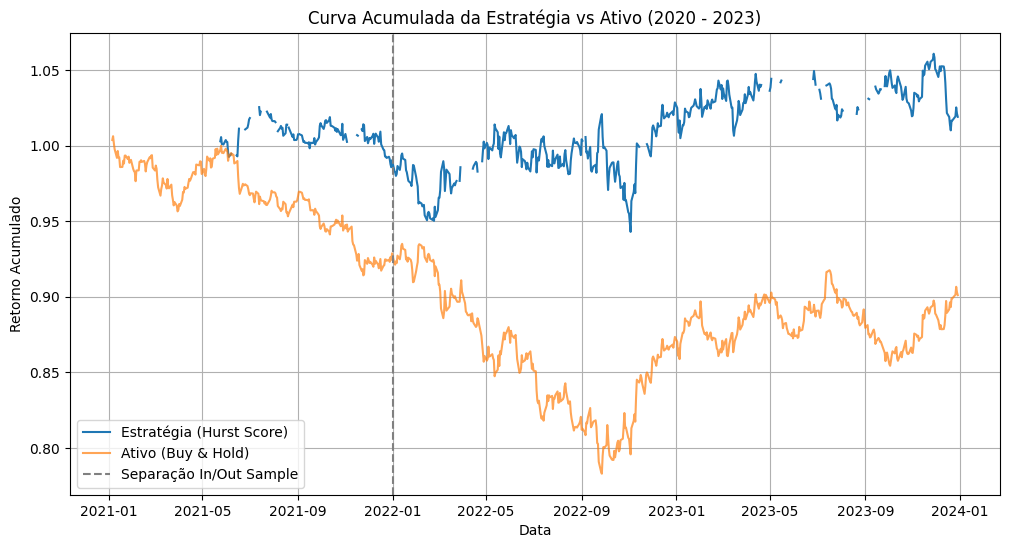

In [60]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['cum_ret_strategy'], label='Estratégia (Hurst Score)')
plt.plot(data.index, data['cum_ret_asset'], label='Ativo (Buy & Hold)', alpha=0.7)
plt.axvline(x=datetime.datetime(2022, 1, 1), color ='gray', linestyle = '--', label='Separação In/Out Sample')
plt.title('Curva Acumulada da Estratégia vs Ativo (2020 - 2023)')
plt.xlabel('Data')
plt.ylabel('Retorno Acumulado')
plt.legend()
plt.grid(True)
plt.show()



Drawdown


Média do Drawdown: -2.32
Mediana do Drawdown: -1.96
Moda do Drawdown: 0.00
Máxima do Drawdown: -8.05


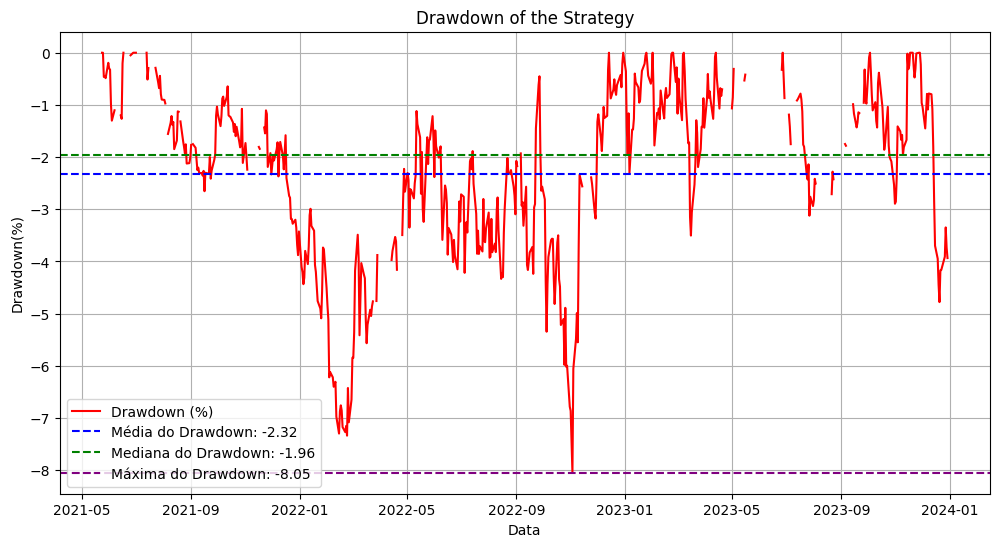

In [61]:
# It calculates the running max of accumulated curve of the strategy
data['running_max'] = data['cum_ret_strategy'].cummax()

# It calculates the drawdown
data['drawdown'] = (data['cum_ret_strategy'] / data['running_max'] - 1 ) *100

# Calculations of statistics

mean_dd = data['drawdown'].mean()
median_dd = data['drawdown'].median()
mode_dd_series= data['drawdown'].mode()
mode_dd = mode_dd_series.iloc[0] if not mode_dd_series.empty else np.nan
max_dd = data['drawdown'].min()

# To display these statistics
print(f'Média do Drawdown: {mean_dd:.2f}')
print(f'Mediana do Drawdown: {median_dd:.2f}')
print(f'Moda do Drawdown: {mode_dd:.2f}')
print(f'Máxima do Drawdown: {max_dd:.2f}')

# Plot of the Drawdown with the statistics
plt.figure(figsize=(12,6))
plt.plot(data.index, data.drawdown, label='Drawdown (%)', color='r')
plt.axhline(mean_dd, color='b', linestyle='--', label =f'Média do Drawdown: {mean_dd:.2f}')
plt.axhline(median_dd, color='g', linestyle='--', label =f'Mediana do Drawdown: {median_dd:.2f}')
plt.axhline(max_dd, color='purple', linestyle='--', label =f'Máxima do Drawdown: {max_dd:.2f}')
plt.title('Drawdown of the Strategy')
plt.xlabel('Data')
plt.ylabel('Drawdown(%)')
plt.legend()
plt.grid(True)
plt.show()
